<a href="https://colab.research.google.com/github/prof22/Handwriting-recognition-system/blob/main/Handwriting_recognition_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A handwriting recognition system interprets handwritten characters or digits from scanned images. In this project, we build a convolutional neural network (CNN) using Keras to recognize handwritten digits from the MNIST dataset, which serves as a great foundation for building full OCR systems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess data: reshape and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# One-hot encode target labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [4]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # Output layer for digits 0–9
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [6]:
# Train model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.9437 - loss: 0.1884 - val_accuracy: 0.9811 - val_loss: 0.0600
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.9836 - loss: 0.0531 - val_accuracy: 0.9844 - val_loss: 0.0520
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9856 - val_loss: 0.0460
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.9911 - loss: 0.0277 - val_accuracy: 0.9877 - val_loss: 0.0394
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9939 - loss: 0.0195 - val_accuracy: 0.9861 - val_loss: 0.0443


In [7]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.9879


In [8]:
# Predict and display some results
predictions = model.predict(x_test[:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


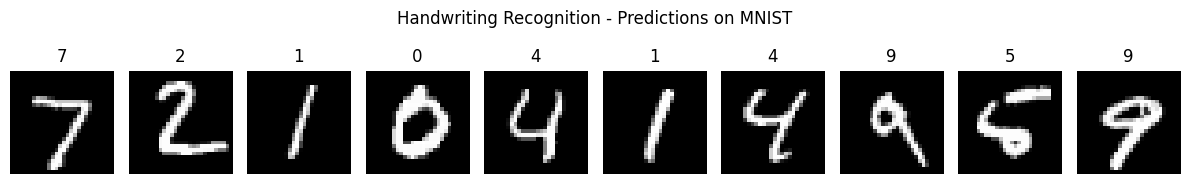

In [9]:
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(np.argmax(predictions[i]))
    plt.axis('off')
plt.suptitle("Handwriting Recognition - Predictions on MNIST")
plt.tight_layout()
plt.show()